## Expert Knowledge Worker

### A question answering agent that is an expert knowledge worker
### To be used by employees of Insurellm, an Insurance Tech company
### The agent needs to be accurate and the solution should be low cost.

This project will use RAG (Retrieval Augmented Generation) to ensure our question/answering assistant has high accuracy.

In [1]:
# imports

import os
import glob
from dotenv import load_dotenv
import gradio as gr

In [2]:
# imports for langchain and Chroma and plotly

from langchain.document_loaders import DirectoryLoader, TextLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.schema import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma
import numpy as np
from sklearn.manifold import TSNE
import plotly.graph_objects as go

In [3]:
# price is a factor for our company, so we're going to use a low cost model

MODEL = "gpt-4o-mini"
db_name = "vector_db"

In [4]:
# Load environment variables in a file called .env

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')

In [5]:
# Read in documents using LangChain's loaders
# Take everything in all the sub-folders of our knowledgebase

folders = glob.glob("knowledge-base/*")

text_loader_kwargs = {'encoding': 'utf-8'}
# If that doesn't work, some Windows users might need to uncomment the next line instead
# text_loader_kwargs={'autodetect_encoding': True}

documents = []
for folder in folders:
    doc_type = os.path.basename(folder)
    loader = DirectoryLoader(folder, glob="**/*.md", loader_cls=TextLoader, loader_kwargs=text_loader_kwargs)
    folder_docs = loader.load()
    for doc in folder_docs:
        doc.metadata["doc_type"] = doc_type
        documents.append(doc)

# Please note:

In the next cell, we split the text into chunks.

2 students let me know that the next cell crashed their computer.  
They were able to fix it by changing the chunk_size from 1,000 to 2,000 and the chunk_overlap from 200 to 400.  
This shouldn't be required; but if it happens to you, please make that change!  
(Note that LangChain may give a warning about a chunk being larger than 1,000 - this can be safely ignored).

_With much thanks to Steven W and Nir P for this valuable contribution._

In [6]:
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)

Created a chunk of size 1088, which is longer than the specified 1000


In [7]:
len(chunks)

123

In [8]:
doc_types = set(chunk.metadata['doc_type'] for chunk in chunks)
print(f"Document types found: {', '.join(doc_types)}")

Document types found: products, company, employees, contracts


## A sidenote on Embeddings, and "Auto-Encoding LLMs"

We will be mapping each chunk of text into a Vector that represents the meaning of the text, known as an embedding.

OpenAI offers a model to do this, which we will use by calling their API with some LangChain code.

This model is an example of an "Auto-Encoding LLM" which generates an output given a complete input.
It's different to all the other LLMs we've discussed today, which are known as "Auto-Regressive LLMs", and generate future tokens based only on past context.

Another example of an Auto-Encoding LLMs is BERT from Google. In addition to embedding, Auto-encoding LLMs are often used for classification.

### Sidenote

In week 8 we will return to RAG and vector embeddings, and we will use an open-source vector encoder so that the data never leaves our computer - that's an important consideration when building enterprise systems and the data needs to remain internal.

In [9]:
# Put the chunks of data into a Vector Store that associates a Vector Embedding with each chunk

embeddings = OpenAIEmbeddings()

# If you would rather use the free Vector Embeddings from HuggingFace sentence-transformers
# Then replace embeddings = OpenAIEmbeddings()
# with:
# from langchain.embeddings import HuggingFaceEmbeddings
# embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

In [10]:
# Check if a Chroma Datastore already exists - if so, delete the collection to start from scratch

if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [11]:
# Create our Chroma vectorstore!

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=db_name)
print(f"Vectorstore created with {vectorstore._collection.count()} documents")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Vectorstore created with 123 documents


# Here we are creating our vector database and it is so easy because of its integration with langchain.

The parameters we passed are -
1. **chunks** - The chunks that we got after doing the langchain text_splitter of size 1000 character each roughly.
2. **embedding** - This is the embedding model that we want to use. Here we are using OpenAI embedding module.
3. **persist_directory** - This is the name of the database where we want to persist our embedding.

**Note - We can also create vectors from entire documents instead of chunks**

Then we can use the _collection.count() to get the number of documents in the vector store.

In [22]:
# Get one vector and find how many dimensions it has

collection = vectorstore._collection
print(collection.get(limit=1, include=["embeddings"])["embeddings"][0])
sample_embedding = collection.get(limit=1, include=["embeddings"])["embeddings"][0]
dimensions = len(sample_embedding)
print(f"The vectors have {dimensions:,} dimensions")

[-0.01153026 -0.01437974 -0.00741978 ... -0.00142909 -0.02827179
 -0.01826728]
The vectors have 1,536 dimensions


### Lets see the above method in more detail

1. _collection returns a collection of the documents.

2. Below is one collection

   **print(collection.get(limit=1))**

    Output -
   ```
   {'ids': ['68824e55-1ced-4d1a-bae7-2a180d0b4de6'], 'embeddings': None, 'documents': ['# Product Summary\n\n# Rellm: AI-Powered Enterprise Reinsurance Solution\n\n## Summary\n\nRellm is an innovative enterprise reinsurance product developed by Insurellm, designed to transform the way reinsurance companies operate. Harnessing the power of artificial intelligence, Rellm offers an advanced platform that redefines risk management, enhances decision-making processes, and optimizes operational efficiencies within the reinsurance industry. With seamless integrations and robust analytics, Rellm enables insurers to proactively manage their portfolios and respond to market dynamics with agility.\n\n## Features\n\n### AI-Driven Analytics\nRellm utilizes cutting-edge AI algorithms to provide predictive insights into risk exposures, enabling users to forecast trends and make informed decisions. Its real-time data analysis empowers reinsurance professionals with actionable intelligence.'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [{'source': 'knowledge-base/products/Rellm.md', 'doc_type': 'products'}]}
   
   ```

Lets also see the embedding which is not included if we do not mention it explicitly.

**print(collection.get(limit=1, include=["embeddings"]))**
Output -
```
Collection(name=langchain)
{'ids': ['68824e55-1ced-4d1a-bae7-2a180d0b4de6'], 'embeddings': array([[-0.01153026, -0.01437974, -0.00741978, ..., -0.00142909,
        -0.02827179, -0.01826728]]), 'documents': None, 'uris': None, 'included': ['embeddings'], 'data': None, 'metadatas': None}
```


Lets see in more detail
**print(collection.get(limit=1, include=["embeddings"])["embeddings"][0])**

Output -

```
[-0.01153026 -0.01437974 -0.00741978 ... -0.00142909 -0.02827179
 -0.01826728]
```

4. Then we are retrieving our sample embedding. We pass limit as 1 to get only one embedding. Then we wanted to get the embedding itself.

As we can see the vector embeddings are simply meaningless numbers to human but can be understood by the llm.


## Visualizing the Vector Store

Let's take a minute to look at the documents and their embedding vectors to see what's going on.

In the code below-
1. We are calling collection to get the documents , embeddings and metadatas.
2. Then we can take the vectos and put them in an arrat of vectors.
3. The put the documents in a documents array
4. And the doc-types in a doc_type array

In [24]:
# Prework

result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
doc_types = [metadata['doc_type'] for metadata in result['metadatas']]
colors = [['blue', 'green', 'red', 'orange'][['products', 'employees', 'contracts', 'company'].index(t)] for t in doc_types]

Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


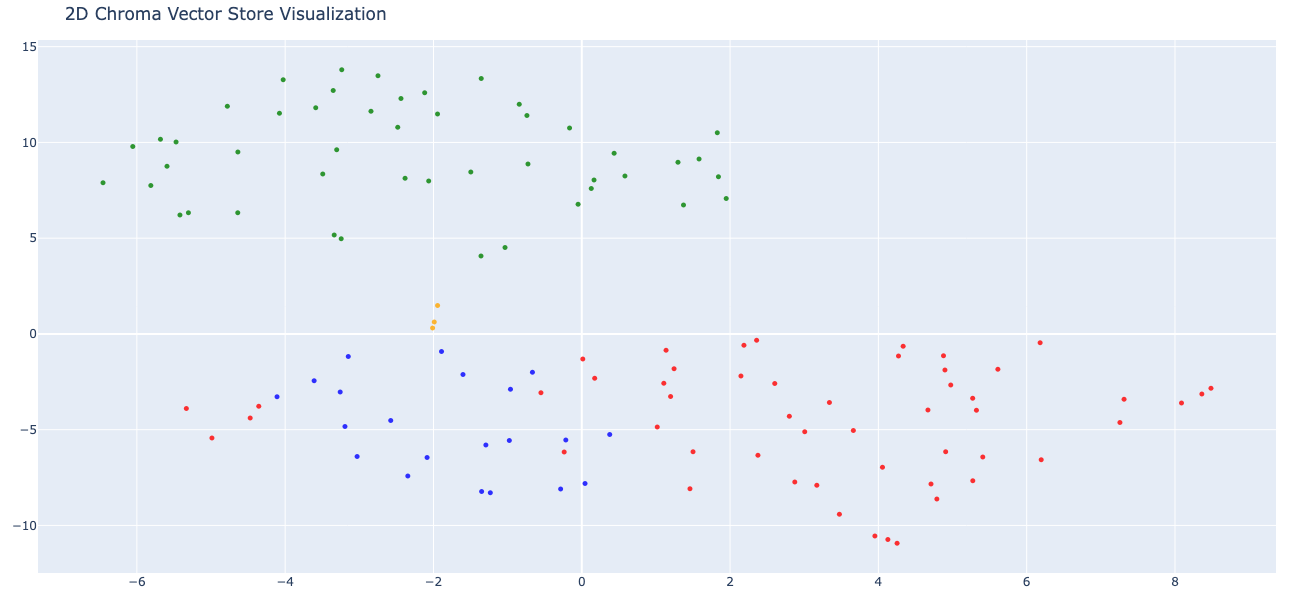

In [25]:
# We humans find it easier to visalize things in 2D!
# Reduce the dimensionality of the vectors to 2D using t-SNE
# (t-distributed stochastic neighbor embedding)

tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

#Then we will use Plotly to draw the dimensions
# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='2D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x',yaxis_title='y'),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

#### Here is how it looks -
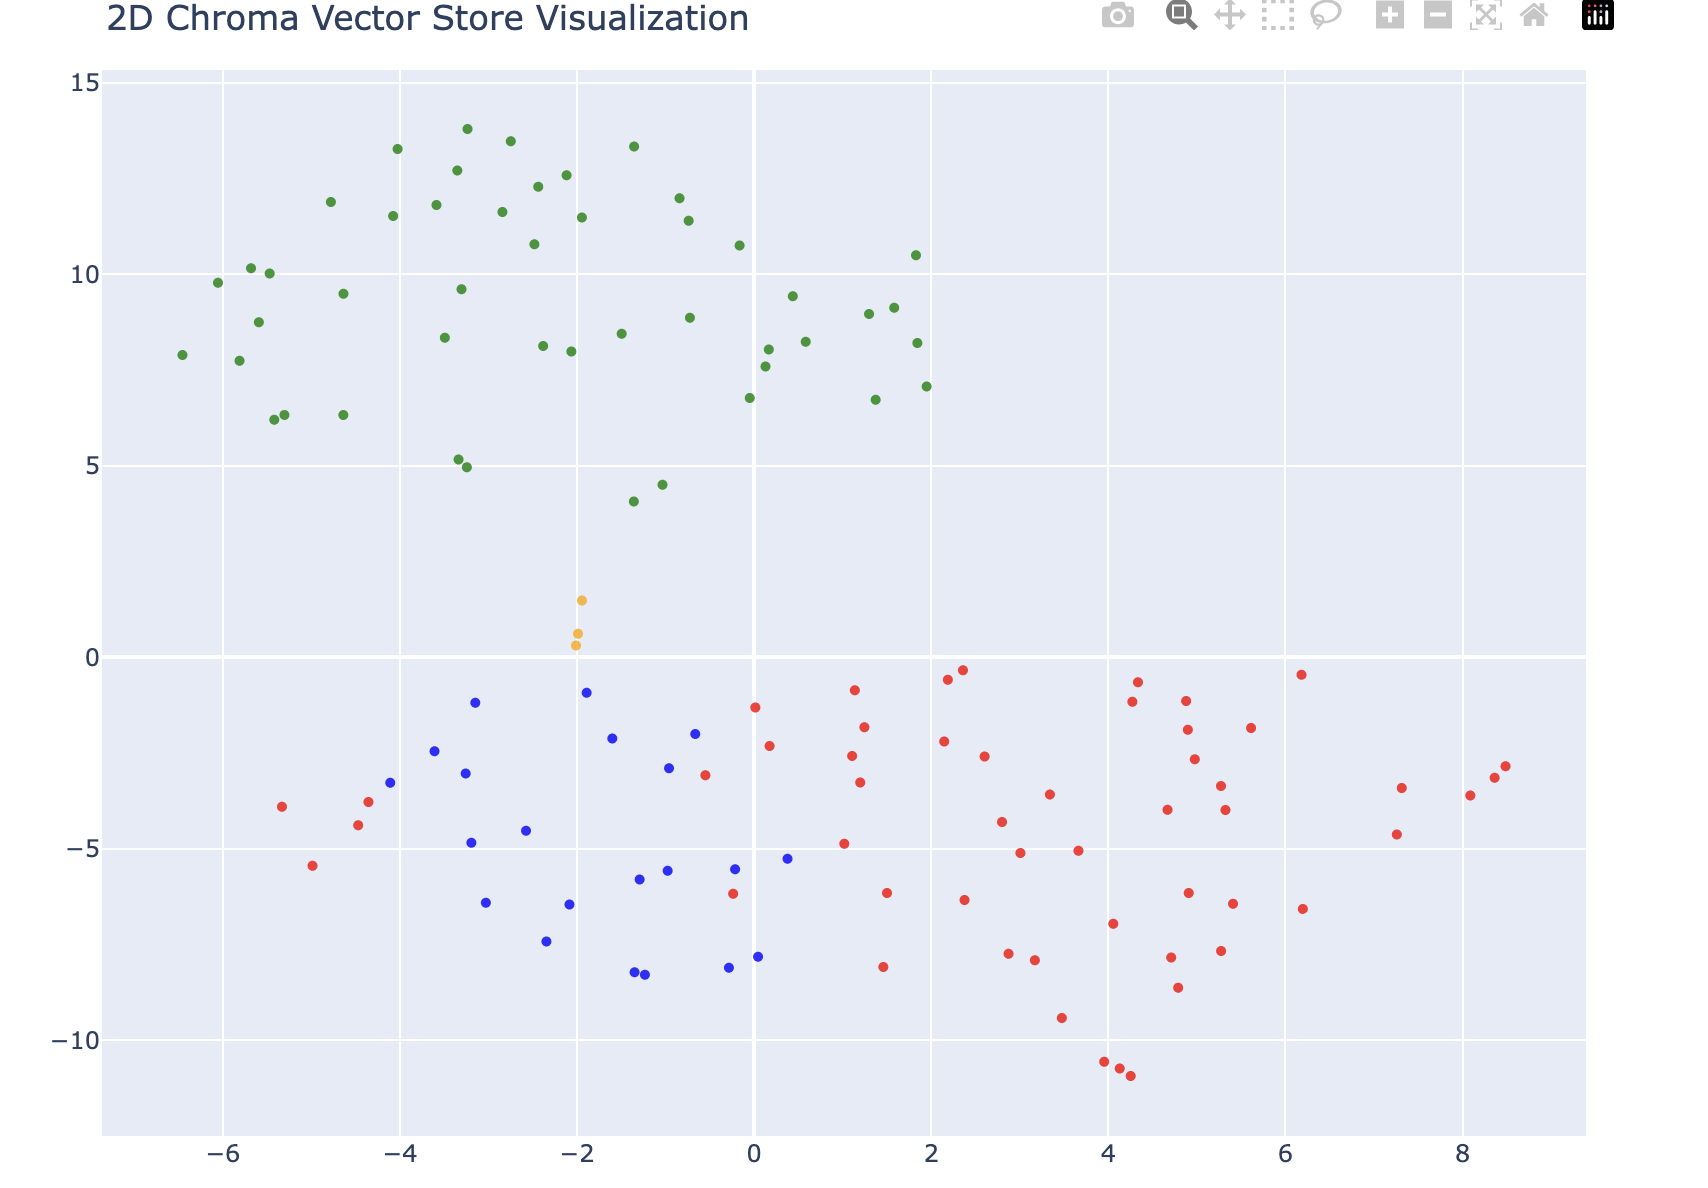

The green dots represent the chunks of text plucked out of employee documents
The red dots represent chunks of documents from contracts
Blue is product
yellow is about folder

**Note - When we passed the chunks to openAIEmbeddings model for vectorizing , we did not send the doc_type metadata . We just gave it the chunk of text and asked it to convert it to vector.** 

**But we can see based on the chunks , the type metadata was obtained and these chunks are seperated out in the representation.
This is because the position of the chunks with same meaning will be near each other. So all chunks with employee information will group near each other.**

**Also we can see some contract chunks are nearer to the product chunks , but this is because the chunk represents the contracts that the client has signed for. Therefore meaningfully the chunk are related and therefore close.**


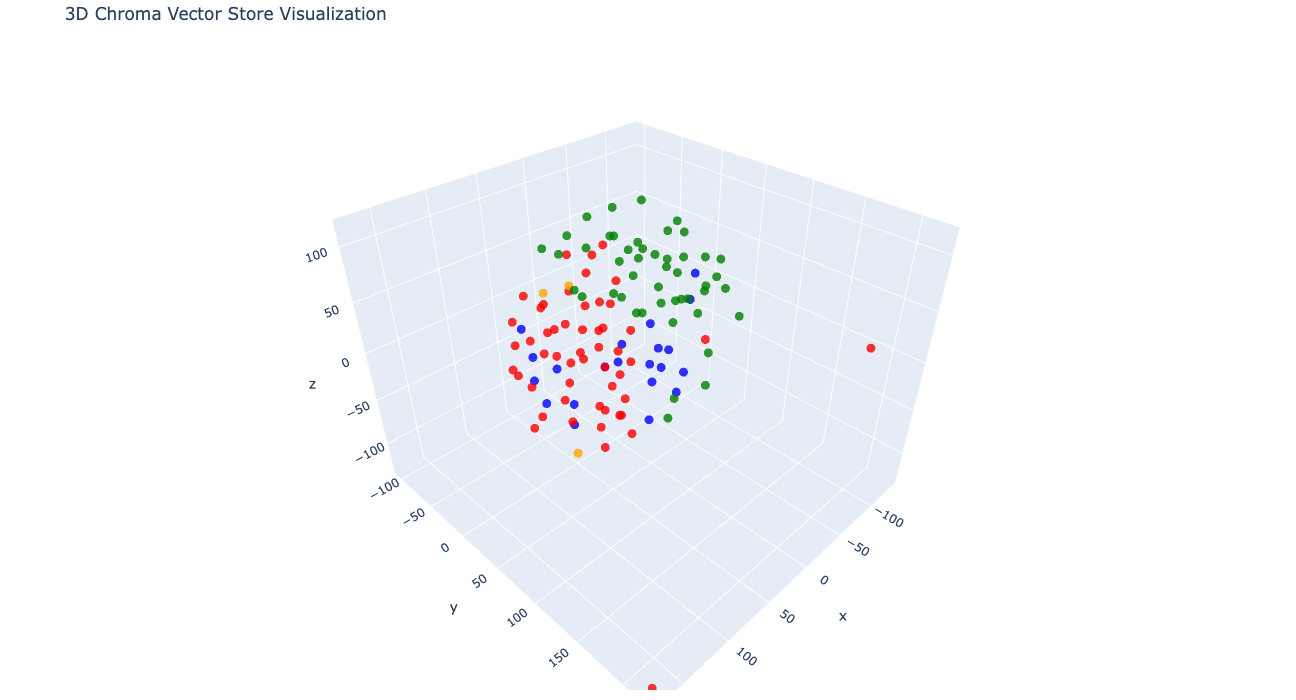

In [26]:
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900,
    height=700,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()